In [1]:
BAE_res_path = "logs/ICL_steer_256_norm"
SAE_res_path = "logs/ICL_steer_SAE_norm"
gate_res_path = "logs/ICL_steer_SAE_gate_norm"
topk_SAE_res_path = "logs/ICL_steer_SAE_topk_norm"

In [2]:
import pickle
import os
import re

BAE_res_x = []
BAE_res_y = []
for filename in os.listdir(BAE_res_path):
    if filename.endswith('.pkl'):
        match = re.search(r'_strength([0-9.]+)', filename)
        if match:
            strength = float(match.group(1))
            with open(os.path.join(BAE_res_path, filename), 'rb') as f:
                data = pickle.load(f)
                BAE_res_x.append(strength)
                BAE_res_y.append(data['results'].item())

BAE_res_x, BAE_res_y = zip(*sorted(zip(BAE_res_x, BAE_res_y)))
BAE_res_x = list(BAE_res_x)
BAE_res_y = list(BAE_res_y)

SAE_res_x = []
SAE_res_y = []
for filename in os.listdir(SAE_res_path):
    if filename.endswith('.pkl'):
        match = re.search(r'_strength([0-9.]+)', filename)
        if match:
            strength = float(match.group(1))
            with open(os.path.join(SAE_res_path, filename), 'rb') as f:
                data = pickle.load(f)
                SAE_res_x.append(strength)
                SAE_res_y.append(data['results'].item())

SAE_res_x, SAE_res_y = zip(*sorted(zip(SAE_res_x, SAE_res_y)))
SAE_res_x = list(SAE_res_x)
SAE_res_y = list(SAE_res_y)

gate_res_x = []
gate_res_y = []
for filename in os.listdir(gate_res_path):
    if filename.endswith('.pkl'):
        match = re.search(r'_strength([0-9.]+)', filename)
        if match:
            strength = float(match.group(1))
            with open(os.path.join(gate_res_path, filename), 'rb') as f:
                data = pickle.load(f)
                gate_res_x.append(strength)
                gate_res_y.append(data['results'].item())

gate_res_x, gate_res_y = zip(*sorted(zip(gate_res_x, gate_res_y)))
gate_res_x = list(gate_res_x)
gate_res_y = list(gate_res_y)

topk_SAE_res_x = []
topk_SAE_res_y = []
for filename in os.listdir(topk_SAE_res_path):
    if filename.endswith('.pkl'):
        match = re.search(r'_strength([0-9.]+)', filename)
        if match:
            strength = float(match.group(1))
            with open(os.path.join(topk_SAE_res_path, filename), 'rb') as f:
                data = pickle.load(f)
                topk_SAE_res_x.append(strength)
                topk_SAE_res_y.append(data['results'].item())

topk_SAE_res_x, topk_SAE_res_y = zip(*sorted(zip(topk_SAE_res_x, topk_SAE_res_y)))
topk_SAE_res_x = list(topk_SAE_res_x)
topk_SAE_res_y = list(topk_SAE_res_y)

(array([-0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,
         0.4 ]),
 [Text(0, -0.05, '−0.05'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.05, '0.05'),
  Text(0, 0.10000000000000002, '0.10'),
  Text(0, 0.15000000000000002, '0.15'),
  Text(0, 0.2, '0.20'),
  Text(0, 0.25000000000000006, '0.25'),
  Text(0, 0.30000000000000004, '0.30'),
  Text(0, 0.35000000000000003, '0.35'),
  Text(0, 0.4, '0.40')])

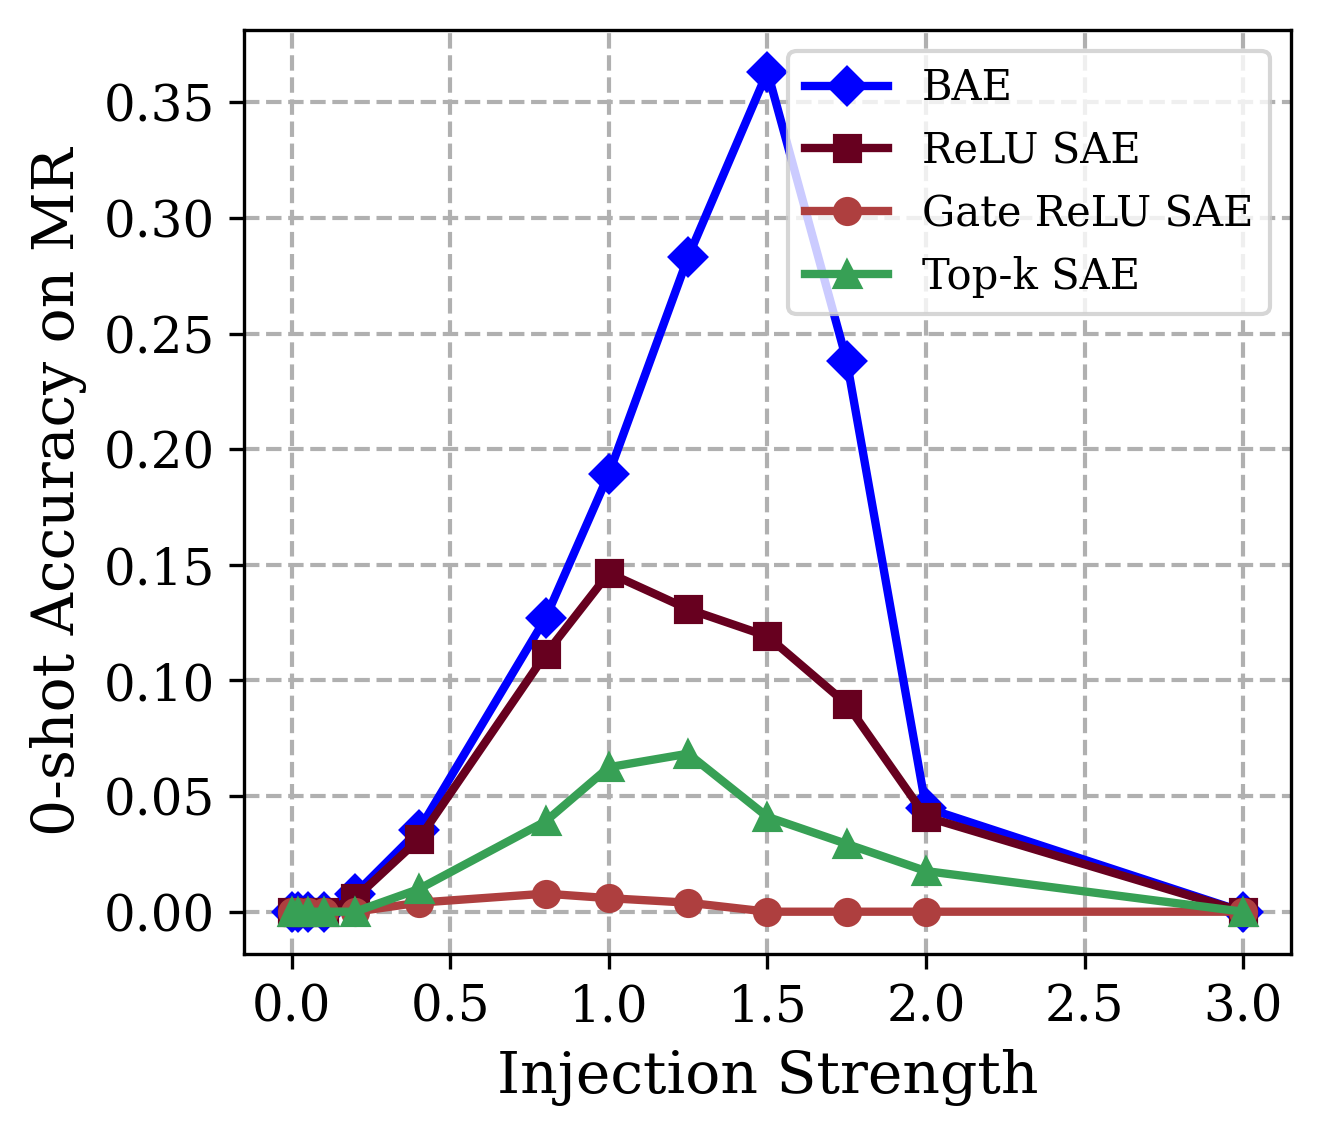

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker
plt.style.use('default')
plt.rc('font',family='Cambria Math')
plt.rcParams['font.family'] = 'serif'
plt.rc("mathtext", fontset = 'stix')
plt.rcParams['font.serif'] = ['Cambria Math'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(4.5,4), dpi=300)

ax.plot(BAE_res_x, BAE_res_y, marker='D', label='BAE', linewidth=2, color='blue')
ax.plot(SAE_res_x, SAE_res_y, marker='s', label='ReLU SAE', linewidth=2, color='#67001f')
ax.plot(gate_res_x, gate_res_y, marker='o', label='Gate ReLU SAE', linewidth=2, color='#ae3f3f')
ax.plot(topk_SAE_res_x, topk_SAE_res_y, marker='^', label='Top-k SAE', linewidth=2, color='#37a055')
plt.grid(True, which='major', linestyle='--', linewidth=1)
ax.set_xlabel('Injection Strength', fontsize=14)
ax.set_ylabel('0-shot Accuracy on MR', fontsize=14)
plt.legend(fontsize=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)